The goal of this Jupyter notebook is to demonstrate that a naive portfolio outperforms my Markowitz optimized portfolio.

The following lengthy block of code is essentially `markowitiz.py`. It will generate an efficient frontier 50 data points (roughly minimum risk to maximum risk).

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
import math

from pandas.api.types import is_numeric_dtype
from sklearn.covariance import LedoitWolf
from scipy.linalg import solve


np.random.seed(42)

data    = pd.read_csv("../../data/cleaned/cleaned.csv")
returns = pd.read_csv("../../data/cleaned/daily_returns.csv")

dates = data["Date"]

data = data.loc[:, data.columns != "Date"]
returns = returns.loc[:, returns.columns != "Date"]

# First day has no 'daily return', so we drop it
data = data.iloc[1:].reset_index(drop=True)
returns = returns.iloc[1:].reset_index(drop=True)

T = len(returns)
N = returns.shape[1]

for c in returns.columns:
  if not is_numeric_dtype(returns[c]):
    print("ERROR: NON-NUMERIC COLUMN: ", c, "\nData type: ", returns[c].dtype)
    exit(-1)

def estimate_mu_sigma(rets, lookback=None, shrink=True):
  """
  Estimate mean values and covariance matrix of daily returns
  Inputs:
    - rets    : df of daily returns
    - shrink  : Whether or not to use Ledoit-Wolf shrinkage on covariance
    - lookback: Number of rows to use, if None uses all
                - Essentially defining the training data set
  """
  if lookback is not None:
    local_data = rets.iloc[-lookback:]
  else:
    local_data = rets.copy()

  mu = local_data.mean().values.reshape(-1, 1) # (5x1 vector, reshaped for matrix mult)

  if shrink:
    lw = LedoitWolf().fit(local_data.values)
    sigma = lw.covariance_
  else:
    sigma = np.cov(local_data.values, rowvar=False, ddof=1)

  # This is a covariance matrix, it'd better already be symmetric.
  # Nonetheless, we explicitly make it symmetric for safety.
  # - If it weren't symmetric, there could be multiple local optima,
  #     And I'm pretty sure the solver would do this anyway.
  sigma = (sigma + sigma.T) / 2
  return mu, sigma


def solve_min_variance_long_only(Sigma, w_max=None, solver=None):
    """
    Minimum-variance portfolio with long-only constraints.
    - This is the 'safest' portfolio that should change the least (positive or negative)

    Solves:
        minimize      : w^T Sigma w
        Constrained by: sum(w) = 1
                        w >= 0
                        (optional) w <= w_max

    Parameters
    ----------
    Sigma : (N, N) ndarray
        Covariance matrix (daily).
    w_max : float or array-like of shape (N,), optional
        Upper bound(s) on weights. Prevent the model from overfixating on one asset class.
    solver : str
        OSQP is good since we expect a quadratic-like problem

    Returns
    -------
    w_value : (N,) ndarray
        Optimal weights, or None if infeasible/failed.
    status : str
        CVXPY solver status string.
    """
    N = Sigma.shape[0]

    w = cp.Variable(N)  # Portfolio weights

    #cp.quad_form(w, Sigma) assumes we want w^T Sigma w
    objective = cp.Minimize(cp.quad_form(w, Sigma))

    constraints = []                    # Construct constraints
    constraints.append(cp.sum(w) == 1)  # fully invested
    constraints.append(w >= 0)          # long-only (no shorting)

    # Apply asset participation cap if provided
    if w_max is not None:
        # If w_max is a scalar (single value), CVXPY broadcasts it to all classes
        constraints.append(w <= w_max)

    problem = cp.Problem(objective, constraints)

    if solver is not None:
      problem.solve(solver=solver, verbose=False)
    else:
      problem.solve(verbose=False)

    # If solver succeeded, return numeric weights
    if w.value is None:
        return None, problem.status

    return np.asarray(w.value).ravel(), problem.status


def solve_frontier_point_long_only(mu, Sigma, R_target, w_max=None, solver=None):
    """
    Given a target return (daily) that the user wants, provide an 'optimized' portfolio

    Solves:
        minimize      : w^T Sigma w
        Constrained by: sum(w) = 1
                        w >= 0
                        mu^T w = R_target
                        (optional) w <= w_max

    Parameters
    ----------
    mu : (US_Equity, International, Bonds, REITs, Cash) ndarray
        Expected daily returns
    Sigma : (N,N) ndarray
        Covariance matrix
    R_target : float
        User requested daily return
    w_max : float or (N,) array, optional
        Weight caps.
    solver : str
        Solver to use. OSQP is just as good here as it was for min var

    Returns
    -------
    w_value : (N,) ndarray or None
        Optimal weights, or None if infeasible/failed.
    status : str
        CVXPY status.
    """
    mu = np.asarray(mu).reshape(-1)  # ensure shape (N,)
    N = Sigma.shape[0]

    w = cp.Variable(N)

    objective = cp.Minimize(cp.quad_form(w, Sigma))

    constraints = [
        cp.sum(w) == 1,      # fully invested
        w >= 0,              # long-only
        mu @ w == R_target   # hit target return exactly
    ]

    if w_max is not None:
        constraints.append(w <= w_max)

    problem = cp.Problem(objective, constraints)
    if solver is not None:
      problem.solve(solver=solver, verbose=False)
    else:
      problem.solve(verbose=False)

    if w.value is None:
        return None, problem.status

    return np.asarray(w.value).ravel(), problem.status


def compute_portfolio_stats(mu, Sigma, w, annualize=True, trading_days=252):
    """
    Utility helper: compute expected return and volatility for weights w.

    mu: expected daily returns
    Sigma: daily covariance
    w: weights

    Returns dict with daily and (optionally) annualized metrics.
    """
    mu = np.asarray(mu).reshape(-1)
    w = np.asarray(w).reshape(-1)

    exp_ret_daily = float(mu @ w)
    var_daily = float(w.T @ Sigma @ w)
    vol_daily = float(np.sqrt(max(var_daily, 0.0)))

    out = {
        "exp_return_daily": exp_ret_daily,
        "vol_daily": vol_daily,
    }

    if annualize:
        out["exp_return_ann"] = exp_ret_daily * trading_days
        out["vol_ann"] = vol_daily * np.sqrt(trading_days)

    return out


def build_long_only_frontier(mu, Sigma, n_points=50, w_max=None, solver=None):
    """
    Build a long-only efficient frontier by sweeping target returns.

    Important detail:
    - With long-only constraints, not every target return is feasible.
    - The feasible expected-return range is roughly [min(mu), max(mu)] under long-only,
      but in practice the covariance + sum-to-1 can still make some exact equality targets
      numerically finicky.
    - So we generate targets inside a "safe" range and skip infeasible solves.

    Returns
    -------
    frontier : list of dicts
        Each dict includes weights, target return, realized return/vol, status.
    """
    mu = np.asarray(mu).reshape(-1)

    mu_min = float(mu.min())
    mu_max = float(mu.max())

    # Generate safe range
    eps = 1e-12
    R_grid = np.linspace(mu_min + eps, mu_max - eps, n_points)

    frontier = []

    for R_target in R_grid:
        w, status = solve_frontier_point_long_only(mu, Sigma, R_target, w_max=w_max, solver=solver)

        if w is None:
            # Infeasible target return for the constraints, skip it.
            continue

        # Status is actually useless here, because if w was infeasible or unbounded then w was None.
        #   status is always optimal by this line
        stats = compute_portfolio_stats(mu, Sigma, w, annualize=True)
        frontier.append({
            "target_R": float(R_target),
            "status": status,
            "weights": w,
            **stats
        })

    return frontier


# mu is ndarray (US_Equity, International, Bonds, REITs, Cash)
# lookback is user defined (longer results in more historically averaged portfolio)
# - Will need to constrain in UI relative to dataset
# - Long term is more data which is often considered better, but it also means an average
#     derived from older data, meaning it may not reflect future conditions as well
# - Short term simply might result in a bad model
lookback = 252
mu, Sigma = estimate_mu_sigma(returns, lookback=lookback, shrink=True)

# If the condition number is too large, we've got a problem
cond_number = np.linalg.cond(Sigma)
print(f"Assets: {returns.shape[1]}, Lookback days: {lookback}, Condition number of Sigma: {cond_number:.3e}")

if cond_number >= math.pow(10, 5):
  print(f"WARNING: Condition number is greater than 100,000: {cond_number}")

mu_vec = mu.ravel()  # Reshape mu

# Now construct the actual efficient frontier, using 50 points to approximate the curve
frontier = build_long_only_frontier(mu_vec, Sigma, n_points=50, w_max=None)
print("Frontier points (feasible):", len(frontier))

if len(frontier) >= 1:
  print("First frontier point:", frontier[0]["exp_return_ann"], frontier[0]["vol_ann"], frontier[0]["weights"])
else:
   print(
        "Well darn, cvxpy determined the problem was literally unsolvable.\n" \
        + "For literally every target return. Nice one bud."
      )

frontier_df = pd.DataFrame(frontier)

TRADING_DAYS = 252  # How many trading days per year?
frontier_df["exp_return_ann"] = frontier_df["exp_return_daily"] * TRADING_DAYS
frontier_df["vol_ann"] = frontier_df["vol_daily"] * math.sqrt(TRADING_DAYS)

# Show the first few frontier points and the min variance portfolio
pd.set_option('display.precision', 6)
print(frontier_df.head())

frontier_df_head = frontier_df[["target_R", "exp_return_ann", "vol_ann"]].head(12).copy()
frontier_df_head.columns = ["target_R_daily", "exp_return_ann", "vol_ann"]
print(frontier_df_head)

Assets: 5, Lookback days: 252, Condition number of Sigma: 2.679e+01
Frontier points (feasible): 49
First frontier point: 0.04026885241882594 0.04976812960367501 [-4.27916134e-06  3.52712819e-06 -8.63709603e-06 -8.33608695e-06
  1.00001774e+00]
   target_R   status                                            weights  \
0  0.000160  optimal  [-4.2791613372585774e-06, 3.527128194701621e-0...   
1  0.000201  optimal  [0.013345584918552781, 0.03300535027630116, 0....   
2  0.000222  optimal  [0.026112168484158683, 0.012027794773689413, 0...   
3  0.000243  optimal  [0.018134757264242022, 0.03631403359033607, 0....   
4  0.000264  optimal  [0.005940572173037561, 0.06181901975014466, 0....   

   exp_return_daily  vol_daily  exp_return_ann   vol_ann  
0          0.000160   0.003135        0.040269  0.049768  
1          0.000201   0.002967        0.050748  0.047104  
2          0.000222   0.002420        0.055988  0.038418  
3          0.000243   0.002417        0.061228  0.038365  
4         

I'll now simulate each of the portfolios from the derived efficient frontier, and present these results alongside a simulated 1/N naive portfolio. The following section is essentially `simulate.py`.

[12354.25547462 13725.83290572 14710.41707038 14482.02224331
 14156.73051406 14142.25936022 14423.04988073 14703.84040123
 14984.63092174 15265.42144225 15546.21196275 15827.00248326
 16107.79300377 16388.58352428 16669.37404479 16950.16456529
 17230.9550858  17511.74560631 17792.53612681 18073.32664732
 18354.11716783 18634.90768834 18915.69820884 19196.48872935
 19477.27924986 19758.06977037 20038.86029087 20319.65081138
 20600.44133189 20881.2318524  21162.0223729  21442.81289341
 21723.60341392 22004.39393442 22284.95347941 22559.46100642
 22820.31762905 23108.47606045 23382.98358747 23657.49111448
 23931.9986415  24206.50616851 24481.01369553 24755.52122254
 25030.02874956 25294.01734396 25572.27504792 25853.5513306
 26128.05901738 67699.44822881 29782.55360238]
Best portfolio in simulation: idx 49, final value 67699.44822881125


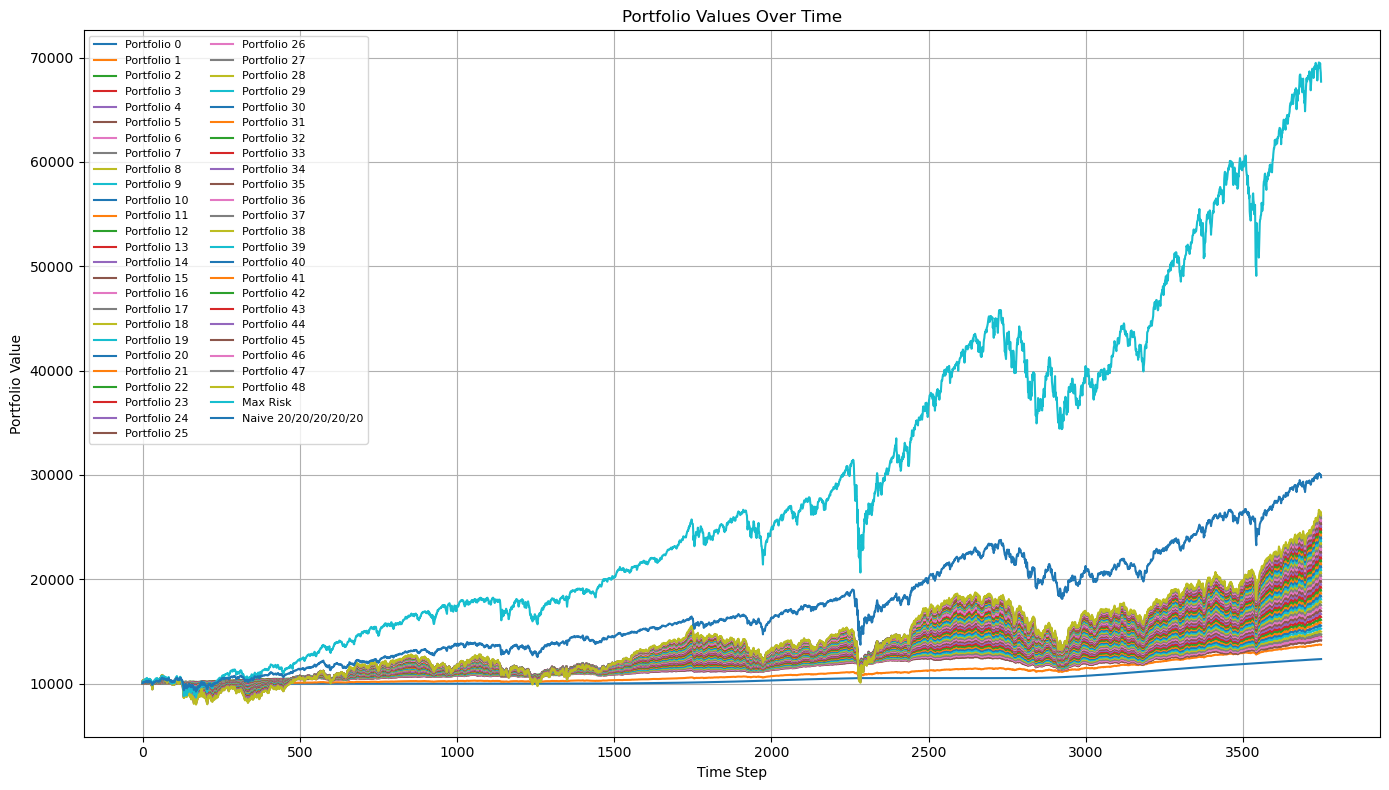

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


STARTING_WEALTH = 10000
classes = ["US_Equity", "International", "Bonds", "REITs", "Cash"]

pf_series = frontier_df["weights"]
pf_arr = pf_series.to_numpy()

max_risk = [1, 0, 0, 0, 0]
naive_dist = [.2, .2, .2, .2, .2]

portfolios = np.vstack([*pf_arr, max_risk, naive_dist])  # shape: (n_portfolios, 5)

# Input values are proportions of invested wealth, so we can trivially multiply.
portfolios = portfolios * STARTING_WEALTH

pfs_over_time = []

for _, row in returns.iterrows():
  # Assumes that data is aligned, matching mu in markowitz.py
  portfolios = portfolios * (1.0 + row[classes].values)
  pfs_over_time.append(portfolios.sum(axis=1).copy())

final_values = portfolios.sum(axis=1)

print(final_values)

pfs_save = pd.DataFrame(pfs_over_time)
pfs_save.to_csv("simulated_portfolios.csv")

print(f"Best portfolio in simulation: idx {np.argmax(final_values)}, final value {max(final_values)}")

plt.figure(figsize=(14, 8))

labels = [f"Portfolio {i}" for i in range(len(final_values) - 2)] + ["Max Risk", "Naive 20/20/20/20/20"]
for i in range(pfs_save.shape[1]):
    plt.plot(pfs_save.index, pfs_save[i], label=labels[i])

plt.title("Portfolio Values Over Time")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


Unfortunately these results are affirmative of my suspicion that the current model is simply incapable of matching the returns of even a naive portfolio distribution. In general, the portfolio value of optimized portfolios creates a uniform band that displays the efficient frontier applied over time, but even a naive distribution of funds significantly outclasses the performance of the efficient frontier portfolios by a wide margin.

I expect that attempting to optimize across the original assets is a more difficult problem, but that assumption remains unproven. If true, we expect the ribbon of frontier portfolios to approach the x-axis.

In [9]:
"""
NOTE: The first code section *must* run before this section, or the function calls will error
"""

tckrs = data.loc[:, data.columns != "DTB3"]

ret = tckrs.pct_change()

dtb3_daily = (data["DTB3"] / 100) / 252
ret = ret.join(dtb3_daily.rename("DTB3"))

lookback = 252
mu, Sigma = estimate_mu_sigma(ret, lookback=lookback, shrink=True)

cond_number = np.linalg.cond(Sigma)
print(f"Assets: {ret.shape[1]}, Lookback days: {lookback}, Condition number of Sigma: {cond_number:.3e}")

if cond_number >= math.pow(10, 5):
  print(f"WARNING: Condition number is greater than 100,000: {cond_number}")

mu_vec = mu.ravel()  # Reshape mu
print(mu_vec)  # We want to know what the highest variance assets are

ret = ret.iloc[1:]
ret.to_csv("asset_daily_returns.csv")

Assets: 10, Lookback days: 252, Condition number of Sigma: 6.481e+01
[0.00016062 0.00027275 0.00113057 0.00031233 0.00058988 0.00026551
 0.00021921 0.00056416 0.00122669 0.00015898]


Frontier points (feasible): 49
First frontier point: 0.04006190426213565 0.04535784535658723 [-2.82673181e-07 -4.24078941e-07  5.23185121e-07 -2.12426850e-06
 -9.99145442e-07 -4.07473751e-07 -2.25500396e-06 -1.07022673e-06
  8.49961586e-07  1.00000619e+00]
   target_R   status                                            weights  \
0  0.000159  optimal  [-2.8267318098264416e-07, -4.2407894078936794e...   
1  0.000203  optimal  [0.35610662444582963, 0.1323215854254042, -6.5...   
2  0.000224  optimal  [0.34881445600673255, 0.13221124868069484, -6....   
3  0.000246  optimal  [0.33732251590061163, 0.13237964006686992, -9....   
4  0.000268  optimal  [0.3252743416478364, 0.13258319208543762, -8.5...   

   exp_return_daily  vol_daily  exp_return_ann   vol_ann  
0          0.000159   0.002857        0.040062  0.045358  
1          0.000203   0.001700        0.051044  0.026992  
2          0.000224   0.001704        0.056535  0.027049  
3          0.000246   0.001727        0.062026  0.027408

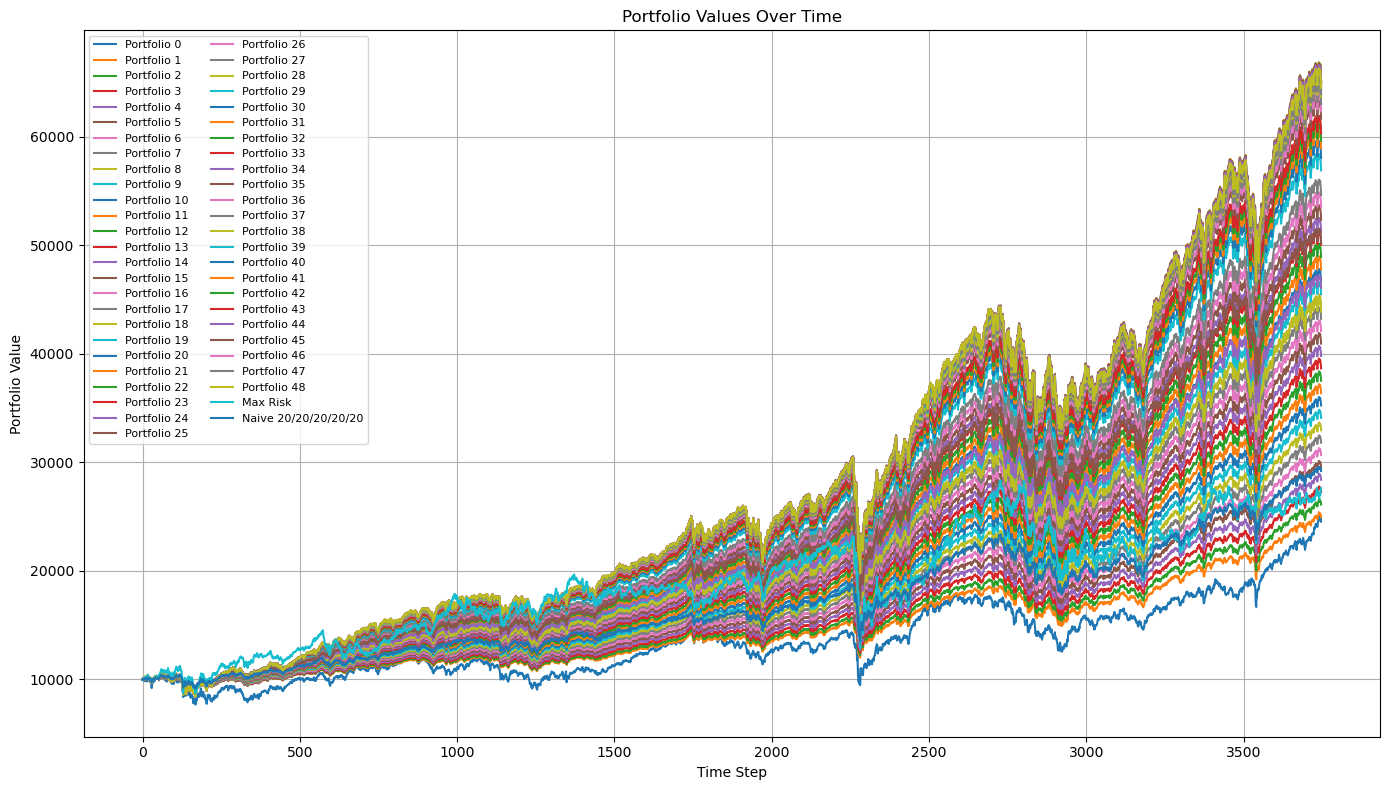

In [10]:
asset_names = ['BIL', 'BND', 'DTB3', 'EFA', 'RWR', 'SPY', 'VBMFX', 'VNQ', 'VTI', 'VXUS']

# Now construct the actual efficient frontier, using 50 points to approximate the curve
frontier = build_long_only_frontier(mu_vec, Sigma, n_points=50, w_max=None)
print("Frontier points (feasible):", len(frontier))

if len(frontier) >= 1:
  print("First frontier point:", frontier[0]["exp_return_ann"], frontier[0]["vol_ann"], frontier[0]["weights"])
else:
   print(
        "Well darn, cvxpy determined the problem was literally unsolvable.\n" \
        + "For literally every target return. Nice one bud."
      )

frontier_df = pd.DataFrame(frontier)

TRADING_DAYS = 252  # How many trading days per year?
frontier_df["exp_return_ann"] = frontier_df["exp_return_daily"] * TRADING_DAYS
frontier_df["vol_ann"] = frontier_df["vol_daily"] * math.sqrt(TRADING_DAYS)

# Show the first few frontier points and the min variance portfolio
pd.set_option('display.precision', 6)
print(frontier_df.head())

frontier_df_head = frontier_df[["target_R", "exp_return_ann", "vol_ann"]].head(12).copy()
frontier_df_head.columns = ["target_R_daily", "exp_return_ann", "vol_ann"]

pf_series = frontier_df["weights"]
pf_arr = pf_series.to_numpy()

max_risk = [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]  # All in on highest variance
naive_dist = [.1, .1, .1, .1, .1, .1, .1, .1, .1, .1]

portfolios = np.vstack([*pf_arr, max_risk, naive_dist])  # shape: (n_portfolios, 5)

# Input values are proportions of invested wealth, so we can trivially multiply.
portfolios = portfolios * STARTING_WEALTH

pfs_over_time = []

sim_values = ret.iloc[1:]

for _, row in sim_values.iterrows():
  # Assumes that data is aligned, matching mu in markowitz.py
  portfolios = portfolios * (1.0 + row[asset_names].values)
  pfs_over_time.append(portfolios.sum(axis=1).copy())

final_values = portfolios.sum(axis=1)

print(final_values)

pfs_save = pd.DataFrame(pfs_over_time)
pfs_save.to_csv("simulated_portfolios_individual_assets.csv")

print(f"Best portfolio in simulation: idx {np.argmax(final_values)}, final value {max(final_values)}")

plt.figure(figsize=(14, 8))

labels = [f"Portfolio {i}" for i in range(len(final_values) - 2)] + ["Max Risk", "Naive 20/20/20/20/20"]
for i in range(pfs_save.shape[1]):
    plt.plot(pfs_save.index, pfs_save[i], label=labels[i])

plt.title("Portfolio Values Over Time")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

This is a truly fascinating result, and it implies my assumption that averaging assets into abstract representative classes results in fewer, cleaner signals, resulting in an easier optimization. I believe the insight that my assumption brushed over is that Markowitz optimization relies on exploiting differences in mean and covariance so that assets balance each other. Collapsing the relationships between similar assets reduces the model degrees of freedom and meaningfully reduces diversification opportunities. In addition, by averaging assets into abstract class returns, I have implicitly defined categories that are pre-diversified, which may impartially benefit the naive portfolio.

To examine whether collapsing the assets into abstract classes hides meaningful information, we will examine the correlation and covariance matrices of the raw asset returns.

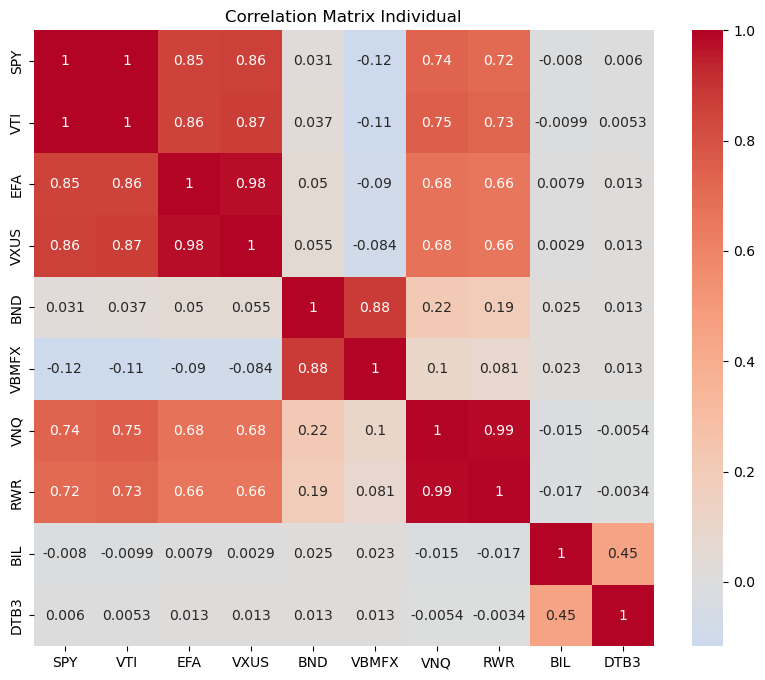

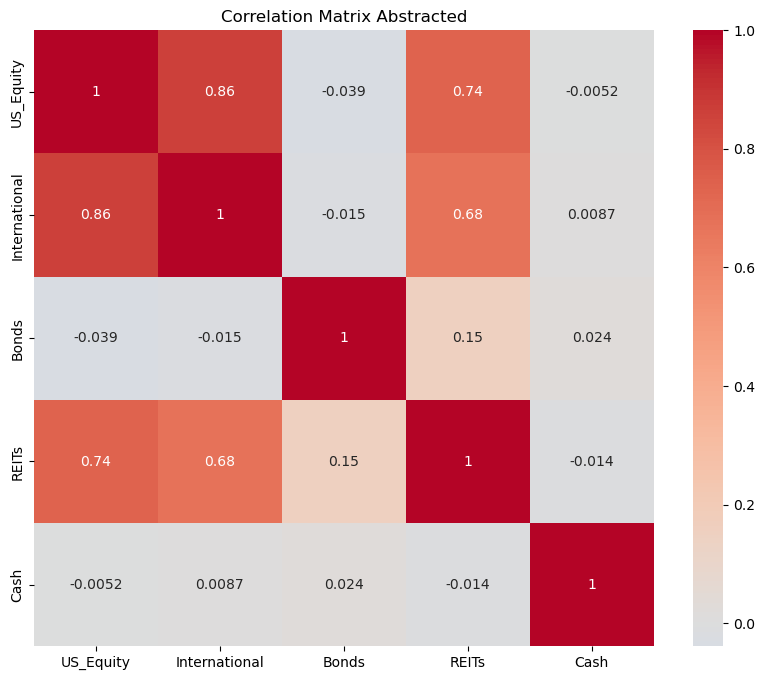

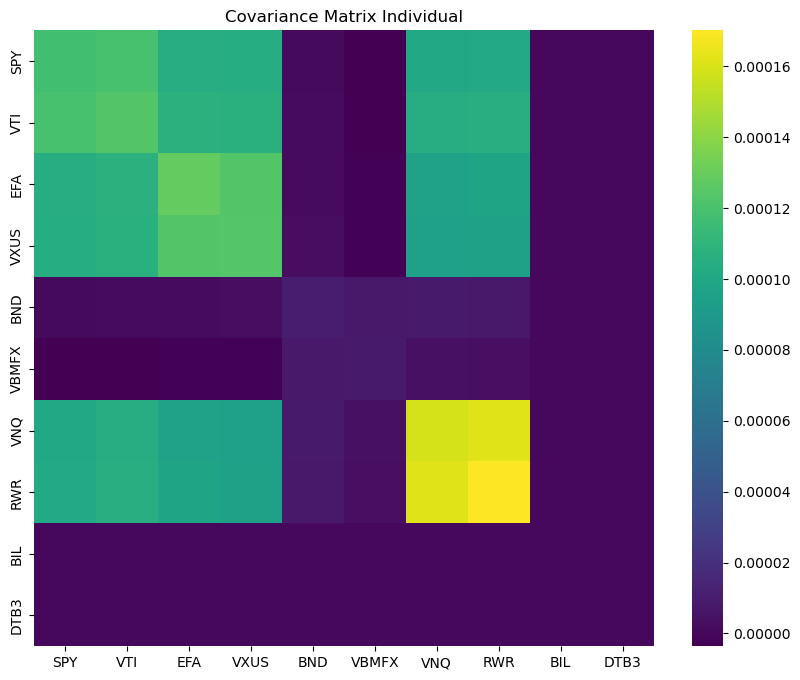

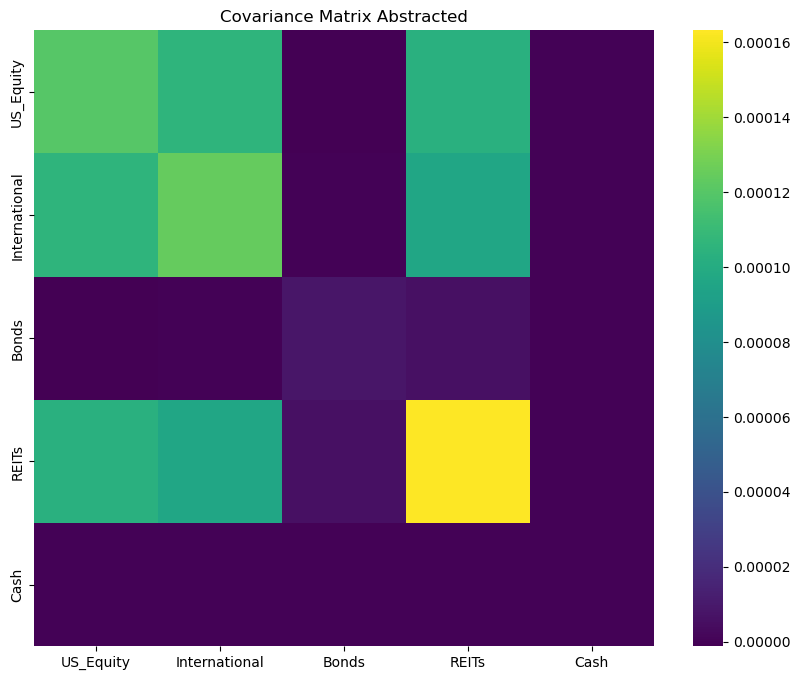

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reorder ret so that the class columns align with their abstracted classes for easier analysis
order = ["SPY", "VTI", "EFA", "VXUS", "BND", "VBMFX", "VNQ", "RWR", "BIL", "DTB3"]
ret_ordered = ret[order]

corr = ret_ordered.corr()
cov = ret_ordered.cov()

corr5 = returns.corr()
cov5 = returns.cov()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Individual")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr5, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Abstracted")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov, cmap="viridis")
plt.title("Covariance Matrix Individual")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov5, cmap="viridis")
plt.title("Covariance Matrix Abstracted")
plt.show()

There does appear to be valuable information that is lost by averaging two assets into an abstract class. Broadly, the assets that contribute to a class have high correlation with each other, which demonstrates that little information is lost by collapsing them into a single class. However, in certain relationships there is a clear loss of information, `BIL` and `DTB3` have an R of 0.45. This moderate correlation could provide meaningful diversification capability to the model, which does not exist in the abstracted class.